In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df=pd.read_csv(r"C:\Users\User\Desktop\Data Analysis\Udemy Data Analysis\Dataset.csv")

In [3]:
df

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18T05:07:05Z,Musical Instruments
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12T19:06:34Z,Musical Instruments
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26T18:34:57Z,Musical Instruments
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21T23:48:18Z,Musical Instruments
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21T23:44:49Z,Musical Instruments
...,...,...,...,...,...,...,...,...,...,...,...
3677,328960,Your Own Site in 45 Min: The Complete Wordpres...,True,120,1566,29,36,All Levels,4 hours,2015-04-20T22:15:17Z,Web Development
3678,552700,Your Second Course on Piano: Two Handed Playing,True,70,1018,12,22,Beginner Level,5 hours,2015-10-26T20:04:21Z,Musical Instruments
3679,631754,Zend Framework 2: Learn the PHP framework ZF2 ...,True,40,723,130,37,All Levels,6.5 hours,2015-11-11T18:55:45Z,Web Development
3680,1225194,Zoho Books Gestion Financière d'Entreprise pas...,False,Free,229,0,33,All Levels,2 hours,2017-05-26T16:45:55Z,Business Finance


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3682 entries, 0 to 3681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   course_id            3682 non-null   int64 
 1   course_title         3682 non-null   object
 2   is_paid              3682 non-null   bool  
 3   price                3682 non-null   object
 4   num_subscribers      3682 non-null   int64 
 5   num_reviews          3682 non-null   int64 
 6   num_lectures         3682 non-null   int64 
 7   level                3682 non-null   object
 8   content_duration     3682 non-null   object
 9   published_timestamp  3682 non-null   object
 10  subject              3682 non-null   object
dtypes: bool(1), int64(4), object(6)
memory usage: 291.4+ KB


In [5]:
df.describe()

,course_id,num_subscribers,num_reviews,num_lectures
count,3.682000e+03,3682.000000,3682.000000,3682.000000
mean,6.766121e+05,3194.230310,156.093156,40.065182
std,3.436355e+05,9499.378361,934.957204,50.373299
min,8.324000e+03,0.000000,0.000000,0.000000
25%,4.078430e+05,110.250000,4.000000,15.000000
50%,6.885580e+05,911.500000,18.000000,25.000000
75%,9.617515e+05,2540.250000,67.000000,45.000000
max,1.282064e+06,268923.000000,27445.000000,779.000000


In [6]:
df.columns

Index(['course_id', 'course_title', 'is_paid', 'price', 'num_subscribers',
       'num_reviews', 'num_lectures', 'level', 'content_duration',
       'published_timestamp', 'subject'],
      dtype='object')

In [7]:
df.isnull().sum()

course_id              0
course_title           0
is_paid                0
price                  0
num_subscribers        0
num_reviews            0
num_lectures           0
level                  0
content_duration       0
published_timestamp    0
subject                0
dtype: int64

In [8]:
df.head()

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18T05:07:05Z,Musical Instruments
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12T19:06:34Z,Musical Instruments
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26T18:34:57Z,Musical Instruments
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21T23:48:18Z,Musical Instruments
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21T23:44:49Z,Musical Instruments


In [15]:
df['price'] = pd.to_numeric(
    df['price'].replace('Free', '0').str.replace('$', '', regex=False)
)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3682 entries, 0 to 3681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   course_id            3682 non-null   int64 
 1   course_title         3682 non-null   object
 2   is_paid              3682 non-null   bool  
 3   price                3682 non-null   int64 
 4   num_subscribers      3682 non-null   int64 
 5   num_reviews          3682 non-null   int64 
 6   num_lectures         3682 non-null   int64 
 7   level                3682 non-null   object
 8   content_duration     3682 non-null   object
 9   published_timestamp  3682 non-null   object
 10  subject              3682 non-null   object
dtypes: bool(1), int64(5), object(5)
memory usage: 291.4+ KB


In [19]:
def convert_duration(x):
    if 'hour' in x:
        return float(x.replace('hours', '').replace('hour', '').strip())
    
    elif 'min' in x:
        minutes = float(x.replace('mins', '').replace('min', '').strip())
        return minutes / 60  # convert to hours
    
    else:
        return None  # safety

df['content_duration'] = df['content_duration'].apply(convert_duration)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3682 entries, 0 to 3681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   course_id            3682 non-null   int64  
 1   course_title         3682 non-null   object 
 2   is_paid              3682 non-null   bool   
 3   price                3682 non-null   int64  
 4   num_subscribers      3682 non-null   int64  
 5   num_reviews          3682 non-null   int64  
 6   num_lectures         3682 non-null   int64  
 7   level                3682 non-null   object 
 8   content_duration     326 non-null    float64
 9   published_timestamp  3682 non-null   object 
 10  subject              3682 non-null   object 
dtypes: bool(1), float64(1), int64(5), object(4)
memory usage: 291.4+ KB


In [21]:
df['published_timestamp'] = pd.to_datetime(df['published_timestamp'])

df['year'] = df['published_timestamp'].dt.year
df['month'] = df['published_timestamp'].dt.month

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3682 entries, 0 to 3681
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   course_id            3682 non-null   int64              
 1   course_title         3682 non-null   object             
 2   is_paid              3682 non-null   bool               
 3   price                3682 non-null   int64              
 4   num_subscribers      3682 non-null   int64              
 5   num_reviews          3682 non-null   int64              
 6   num_lectures         3682 non-null   int64              
 7   level                3682 non-null   object             
 8   content_duration     326 non-null    float64            
 9   published_timestamp  3682 non-null   datetime64[ns, UTC]
 10  subject              3682 non-null   object             
 11  year                 3682 non-null   int64              
 12  month               

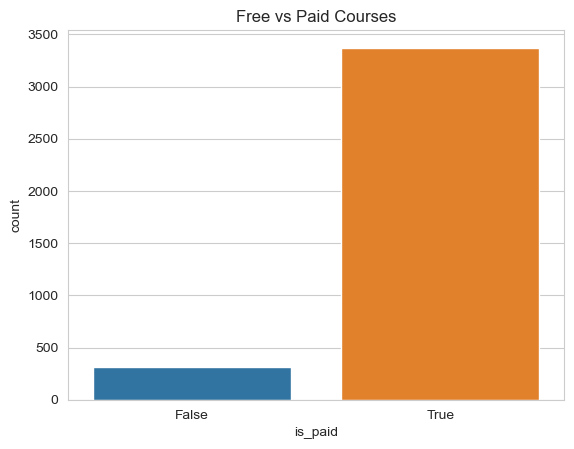

In [24]:
sns.countplot(x='is_paid',data=df)
plt.title("Free vs Paid Courses")
plt.show()

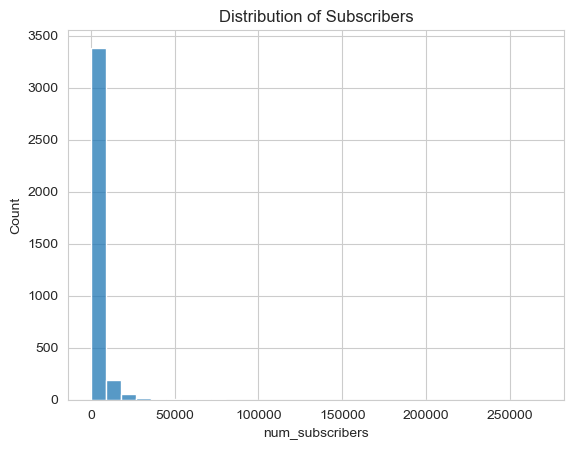

In [25]:
sns.histplot(df['num_subscribers'], bins=30)
plt.title("Distribution of Subscribers")
plt.show()

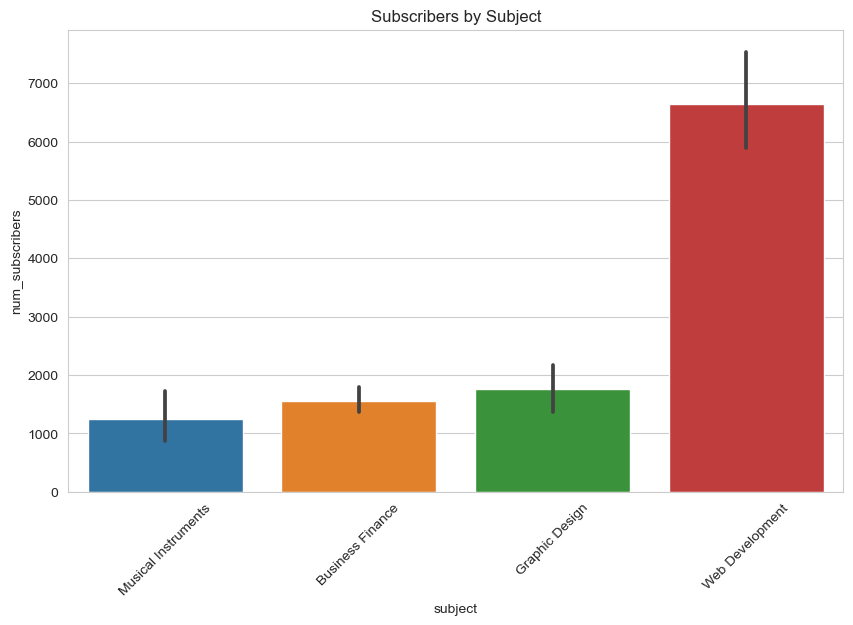

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(x='subject', y='num_subscribers', data=df)
plt.xticks(rotation=45)
plt.title("Subscribers by Subject")
plt.show()

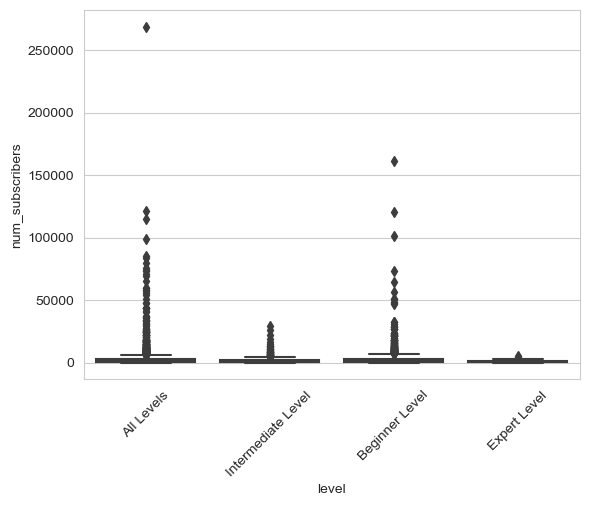

In [27]:
sns.boxplot(x='level', y='num_subscribers', data=df)
plt.xticks(rotation=45)
plt.show()

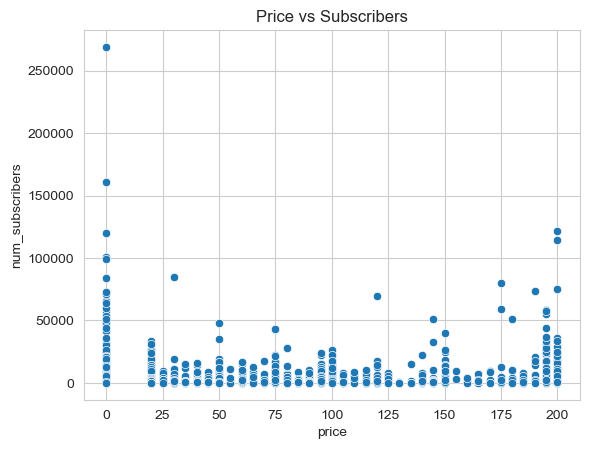

In [28]:
sns.scatterplot(x='price', y='num_subscribers', data=df)
plt.title("Price vs Subscribers")
plt.show()

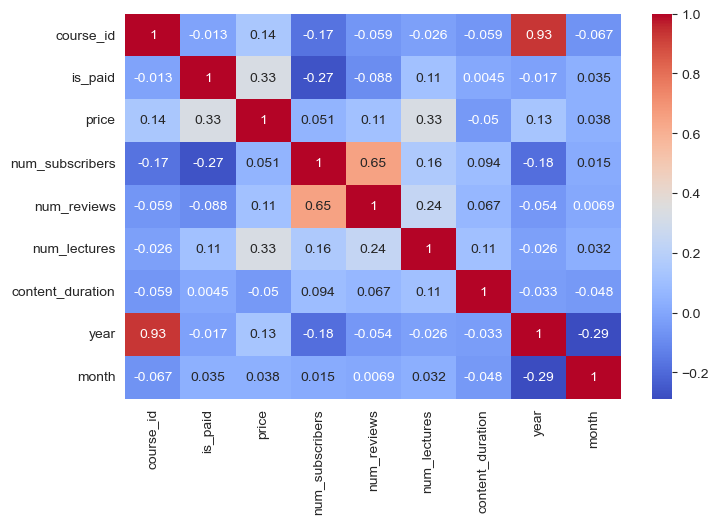

In [29]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [30]:
threshold = df['num_subscribers'].quantile(0.75)

df['is_successful'] = df['num_subscribers'] >= threshold

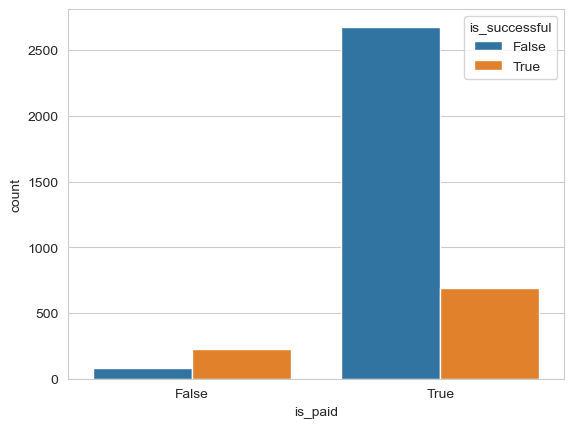

In [31]:
sns.countplot(x='is_paid', hue='is_successful', data=df)
plt.show()

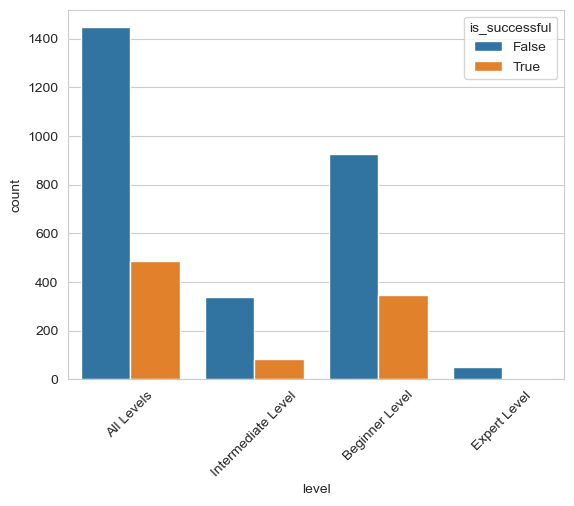

In [32]:
sns.countplot(x='level', hue='is_successful', data=df)
plt.xticks(rotation=45)
plt.show()

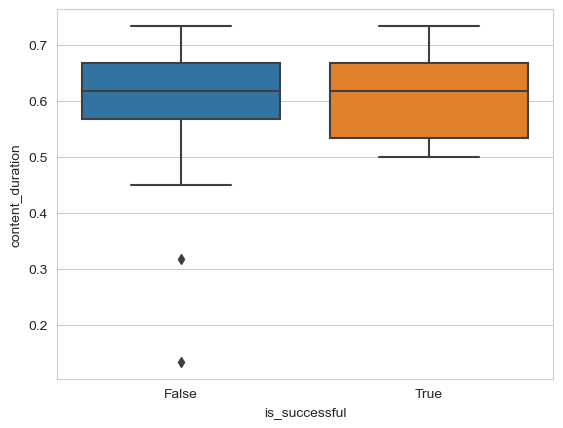

In [33]:
sns.boxplot(x='is_successful', y='content_duration', data=df)
plt.show()

In [34]:
df['revenue'] = df['price'] * df['num_subscribers']
df.groupby('subject')['revenue'].sum().sort_values(ascending=False)

subject
Web Development        630843775
Business Finance       123796395
Graphic Design          76983170
Musical Instruments     53359055
Name: revenue, dtype: int64

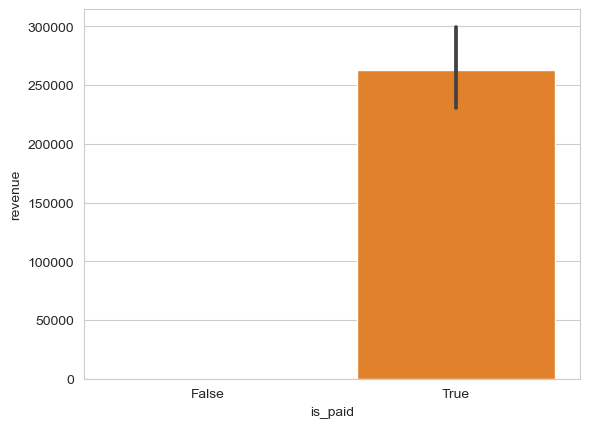

In [35]:
sns.barplot(x='is_paid', y='revenue', data=df)
plt.show()